<!-- ![Accident Plot](banner.jpeg) -->
<img src="banner.jpeg" width="1200">

<!--# Project Title-->
# Exploring Weather, Road, and Time Factors in US Traffic Accidents

## Overview

This project analyzes the US Accidents dataset to identify patterns and factors influencing traffic accidents across the United States. The focus is on spatial and temporal trends, examining when and where accidents most frequently occur, including variations by time of day, day of week, and season.

In addition, environmental and road-related factors such as weather conditions, visibility, and infrastructure features are considered to understand their impact on accident severity.
The dataset is preprocessed by handling missing values, removing outliers, and creating derived features. A Random Forest model is then applied to predict accident severity and identify the most important contributing factors.

The results provide insights into high-risk conditions and time periods, which could support traffic safety improvements and decision-making.


## Business Understanding


#### Business Scenario / Problem Statement

Traffic accidents represent a major public safety issue, leading to significant injuries, fatalities, and economic costs. This project is motivated by the need to better understand the factors that contribute to accident occurrence and severity in order to support more effective prevention strategies.

#### Project Motivation

The project aims to analyze accident data to identify key factors influencing accident occurrence and severity, supporting data-driven safety improvements.

#### Analytical Questions

Key analytical questions include whether accidents are more severe during nighttime, how weather conditions such as precipitation affect accident outcomes, and which road features are associated with higher risk.

#### Stakeholders

The primary stakeholders include transportation departments, urban planners, and traffic safety agencies. The expected benefits of this analysis are improved decision-making, identification of high-risk conditions, and support for policies aimed at enhancing road safety.

#### Expected Benefits

The project aims to analyze accident data to identify key factors influencing accident occurrence and severity, supporting data-driven safety improvements.

## Areas of Analysis

#### Spatial and Temporal Patterns

This section investigates when and where traffic accidents occur by analyzing patterns across time and location. It focuses on variations by hour of day, day of week, season, and geographic distribution across states. The goal is to identify temporal trends and spatial concentrations in accident occurrences.

- At what times during the day do most accidents happen?
- Are there differences between weekdays and weekends?
- Which states or cities have most accidents?
- Are there seasonal patterns (winter vs. summer)?
  
- [X] H1: Accidents occur more frequently during rush hours (7-9 am and 4-6 pm).
- [X] H2: There are more accidents during weekdays (Mo-Fr) compared to weekends (Sa/Su).
- [ ] H3: States with larger populations have significantly more accidents?

#### Environmental Factors

This section examines how environmental conditions influence traffic accidents. It focuses on variables such as weather conditions, visibility, temperature, and wind, aiming to understand their relationship with accident occurrence and severity.

- Does bad weather have an impact on frequency and severity of accidents?
- How does visibility impact accidents?
- Are there more accidents during rain / snow / fog?
- Does temperature have an influence?
  
- [ ] H1: Poor visibility leads to higher accident severity.
- [ ] H2: During rain and snow there are more accidents.
- [ ] H3: Extreme temperatures (very cold/ hot) increase accident risk,
- [ ] H4: Weather conditions have a sinificant impact on severity.

#### Infrastructure Considerations

This section investigates how road and infrastructure features relate to traffic accidents. It focuses on elements such as intersections, traffic signals, road design, and lighting conditions to assess their potential influence on accident occurrence and severity.

- Which road attributes are connected with most severe accidents?
- Do traffic signals have an influence on accident frequency?
- Are accidents more common at intersections, traffic lights, construction etc.?
- Does lighting (day/night) have an effect?

- [ ] H1: Accidents at intersections (junctions) are more common.
- [ ] H2: Lacking or poor lighting increases severity.
- [ ] H3: Traffic signals decrease the severity of accidents.
- [ ] H4: Construction increases accident risk.
- [ ] H5: Night conditions lead to higher severity.


## Data Understanding

This section explains the data available and what it contains.

#### Tasks:
- Load dataset &#x2705;
- Show dataset size (df.shape) &#x2705;
- Inspect structure (df.info()) &#x2705;
- Describe variables (df.describe()) &#x2705;
- Document variables and meaning &#x2705;
- Identify categorical vs numerical columns &#x2705;
- Explore missing values &#x2705;
- Initial visualizations &#x2705;

#### Example topics:
- Number of rows and columns
- Types of variables (numeric, categorical, boolean)
- Key columns such as Severity, Temperature, Visibility
- Missing data patterns


In [1]:
# Load relevant libraries here

# Data Analysis
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
#scipyLinks to an external site.
#statsmodelsLinks to an external site.

In [2]:
# Load the dataset (raw)
df_raw = pd.read_csv("US_Accidents_March23.csv")

# Keep working copy for cleaning and feature engineering (later)
df = df_raw.copy()


In [3]:
# Inspect first five rows
pd.set_option('display.max_columns', None)
df.head()

#pd.reset_option('display.max_columns')

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.9,NaN,91.0,29.68,10.0,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,2016-02-08 05:51:00,37.9,NaN,100.0,29.65,10.0,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,2016-02-08 06:56:00,36.0,33.3,100.0,29.67,10.0,SW,3.5,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,Dayton,Montgomery,OH,45417,US,US/Eastern,KDAY,2016-02-08 07:38:00,35.1,31.0,96.0,29.64,9.0,SW,4.6,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,Dayton,Montgomery,OH,45459,US,US/Eastern,KMGY,2016-02-08 07:53:00,36.0,33.3,89.0,29.65,6.0,SW,3.5,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


In [4]:
# Describe variables / some Statistics

df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


In [5]:
# Inspect structure

df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

In [6]:
# Show dataset size

df.shape

(7728394, 46)

In [7]:
# Check all column headers - their meaning, type and typical values
#
# Source Data Description: https://smoosavi.org/datasets/us_accidents
# Longitude/ Latitude Map of the USA: https://springwatertrails.org/2015/03/gps/
#
#  0 - ID - object - Identifier A-x where x is accident number (corresponds to each row in dataset)
#  1 - Source - object - Source of raw accident data; possible values are Source1, Source2 and Source3
#  2 - Severity - int64 - Shows the severity of the accident, a number between 1 and 4, where 1 indicates the least impact on traffic (i.e., short delay as a result of the accident) and 4 indicates a significant impact on traffic (i.e., long delay).
#  3 - Start_Time - object - Shows start time of the accident in local time zone; format is: YYYY--MM-DD HH:MM:SS (24 h format).
#  4 - End_Time - object - Shows end time of the accident in local time zone. End time here refers to when the impact of accident on traffic flow was dismissed.
#  5 - Start_Lat - float64 - Shows latitude in GPS coordinate of the start point.
#  6 - Start_Lng - float64 - Shows longitude in GPS coordinate of the start point.
#  7 - End_Lat - float64 - Shows latitude in GPS coordinate of the end point.
#  8 - End_Lng - float64 - Shows longitude in GPS coordinate of the end point.
#  9 - Distance(mi) - float64 - The length of the road extent affected by the accident.
# 10 - Desciption - object - Shows natural language description of the accident.
# 11 - Street - object - Shows the street name in address field.
# 12 - City - object - Shows the city in address field.
# 13 - County - object - Shows the county in address field.
# 14 - State - object - Shows the state in address field.
# 15 - Zipcode - object - Shows the zipcode in address field.
# 16 - Country - object - Shows the country in address field.
# 17 - Timezone - object - Shows timezone based on the location of the accident (eastern, central, etc.).	
# 18 - Airport_Code - object - Denotes an airport-based weather station which is the closest one to location of the accident
# 19 - Weather_Timestamp - object - Shows the time-stamp of weather observation record (in local time). Format is: YYYY--MM-DD HH:MM:SS (24 h format).
# 20 - Temperature(F) - float64 - Shows the temperature (in Fahrenheit).
# 21 - Wind_Chill(F) - float64 - Shows the wind chill (in Fahrenheit).
# 22 - Humidity(%) - float64 - Shows the humidity (in percentage).
# 23 - Pressure(in) - float64 - Shows the air pressure (in inches).
# 24 - Visibility(mi) - float64 - Shows visibility (in miles).
# 35 - Wind_Direction - object - Shows wind direction.
# 36 - Wind_Speed(mph) - float64 - Shows wind speed (in miles per hour). This has NaN when it is calm (no wind).
# 27 - Precipitation(in) - float64 - Shows precipitation amount in inches, if there is any.
# 28 - Weather_Condition - object - Shows the weather condition (rain, snow, thunderstorm, fog, etc.)
# 29 - Amenity - bool - A POI annotation which indicates presence of amenity in a nearby location.
# 30 - Bump - bool - A POI annotation which indicates presence of speed bump or hump in a nearby location.
# 31 - Crossing - bool - A POI annotation which indicates presence of crossing in a nearby location.
# 32 - Give_Way - bool - A POI annotation which indicates presence of give_way in a nearby location.
# 33 - Junction - bool - A POI annotation which indicates presence of junction in a nearby location.
# 34 - No_Exit - bool - A POI annotation which indicates presence of no_exit in a nearby location.
# 35 - Railway - bool - A POI annotation which indicates presence of railway in a nearby location.
# 36 - Roundabout - bool - A POI annotation which indicates presence of roundabout in a nearby location.
# 37 - Station - bool - A POI annotation which indicates presence of station in a nearby location.
# 38 - Stop - bool - A POI annotation which indicates presence of stop in a nearby location.
# 39 - Traffic_Calming - bool - A POI annotation which indicates presence of traffic_calming in a nearby location.
# 40 - Traffic_Signal - bool - A POI annotation which indicates presence of traffic_signal in a nearby loction.
# 41 - Turning_Loop - bool - A POI annotation which indicates presence of turning_loop in a nearby location.
# 42 - Sunrise_Sunset - object - Shows the period of day (i.e. day or night) based on sunrise/sunset.
# 43 - Civil_Twilight - object - Shows the period of day (i.e. day or night) based on civil twilight.
# 44 - Nautical_Twilight - object - Shows the period of day (i.e. day or night) based on nautical twilight.
# 45 - Astronomical_Twilight - object - Shows the period of day (i.e. day or night) based on astronomical twilight.


#df["ID"].head()
#df.ID.head()
#df["Source"].unique()
#df["Severity"].unique()
#df["Start_Time"].info
#df["End_Time"].info
#df["Start_Lat"].info
#df["Start_Lng"].info
#df["Distance(mi)"].describe()
#print(df["Description"])
#df[["Street", "City", "County", "State", "Zipcode", "Country"]].head()
#df["Country"].unique()
#df["Street"].nunique() # 336,306
#df["City"].nunique() # 13,678
#df["County"].nunique() # 1,871
#df["State"].nunique() # 49
#df["Zipcode"].nunique() # 825,094
#df["Country"].nunique() # 1 i.e. USA; can eliminate that because it adds no value.
#df["Timezone"].unique() # There are 4 Time Zones i.e. Eastern, Central, Mountain, and Pacific, and there are instances of NaN.
#df["Airport_Code"].nunique() # 2,045
#df["Weather_Timestamp"].info
#df["Temperature(F)"].head()
#df[["Temperature(F)","Wind_Chill(F)","Humidity(%)", "Pressure(in)", "Visibility(mi)", "Wind_Direction"]]
#df["Wind_Direction"].unique() # needs cleaning up because of NaN.
#df[["Wind_Direction", "Wind_Speed(mph)", "Precipitation(in)"]]
#df["Weather_Condition"].head()
#df["Amenity"].value_counts() # 96334 True
#df["Bump"].value_counts() # 3,514 True
#df["Crossing"].value_counts() # 873,763 True
#df["Give_Way"].value_counts() # 36,582 True
#df["Give_Way"].value_counts() # 36,582 True
#df["No_Exit"].value_counts() # 19,545 True
#df["Railway"].value_counts() # 66,979 True
#df["Roundabout"].value_counts() # 249 True
#df["Station"].value_counts() # 201,901 True
#df["Stop"].value_counts() # 214,371 True
#df["Traffic_Calming"].value_counts() # 7,598 True
#df["Traffic_Signal"].value_counts() # 1,143,772 True
#df["Turning_Loop"].value_counts() # 0 True (all are False)
#df[["Sunrise_Sunset","Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight"]].head()
#df["Sunrise_Sunset"].value_counts() # only 2 values: 5,334,553 Day; 2,370,595 Night
#df["Civil_Twilight"].value_counts() # only 2 values: 5,695,619 Day; 2,009,529 Night
#df["Nautical_Twilight"].value_counts() # only 2 valuess: 6,076,156 Day; 1,628,992 Night
#df["Astronomical_Twilight"].value_counts() # only 2 values: 6,377,548 Day; 1,327,600 Night



In [8]:
## Downsampling (only run once)
# Reason: certain actions, functions and modeling later run very slow with full dataset
# Idea: downsample here (by factor of 100) and use smaller dataset. Once successful can switch back.

df_sampled = df.sample(frac=0.01, random_state=42)

In [9]:
# Inspect structure

df_sampled.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 77284 entries, 7133276 to 6135831
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     77284 non-null  object 
 1   Source                 77284 non-null  object 
 2   Severity               77284 non-null  int64  
 3   Start_Time             77284 non-null  object 
 4   End_Time               77284 non-null  object 
 5   Start_Lat              77284 non-null  float64
 6   Start_Lng              77284 non-null  float64
 7   End_Lat                43315 non-null  float64
 8   End_Lng                43315 non-null  float64
 9   Distance(mi)           77284 non-null  float64
 10  Description            77284 non-null  object 
 11  Street                 77157 non-null  object 
 12  City                   77281 non-null  object 
 13  County                 77284 non-null  object 
 14  State                  77284 non-null  object 
 15 

Note that memory usage went down by factor of 100 as well now being less than 100 MB which is much more manageable.

In [10]:
# Convert data types and create new features needed for temporal analysis

# Convert datetime
df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")
df["End_Time"] = pd.to_datetime(df["End_Time"], errors="coerce")

# Create new features
df["Hour"] = df["Start_Time"].dt.hour
df["DayOfWeek"] = df["Start_Time"].dt.dayofweek
df["Duration_min"] = (pd.to_datetime(df["End_Time"]) - df["Start_Time"]).dt.total_seconds() / 60


# Convert datetime
df_sampled["Start_Time"] = pd.to_datetime(df_sampled["Start_Time"], errors="coerce")
df_sampled["End_Time"] = pd.to_datetime(df_sampled["End_Time"], errors="coerce")

# Create new features
df_sampled["Hour"] = df_sampled["Start_Time"].dt.hour
df_sampled["DayOfWeek"] = df_sampled["Start_Time"].dt.dayofweek
df_sampled["Duration_min"] = (pd.to_datetime(df_sampled["End_Time"]) - df_sampled["Start_Time"]).dt.total_seconds() / 60



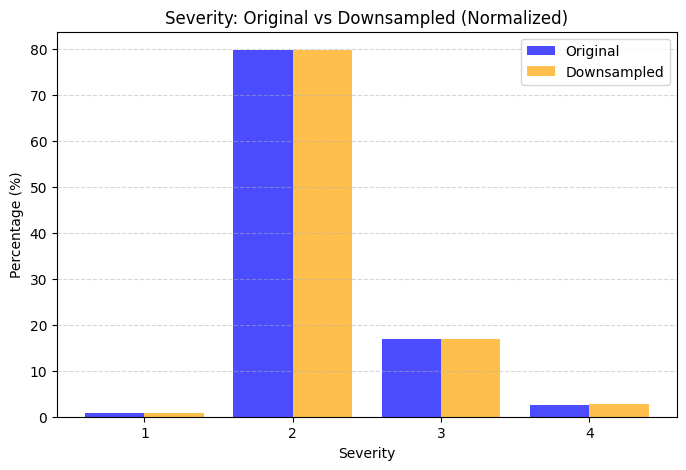

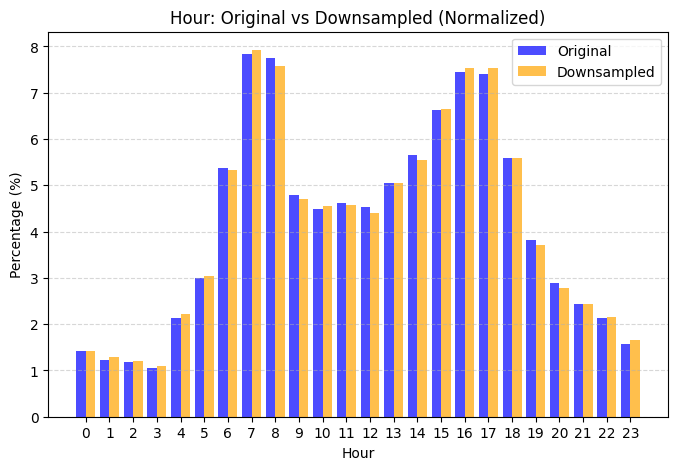

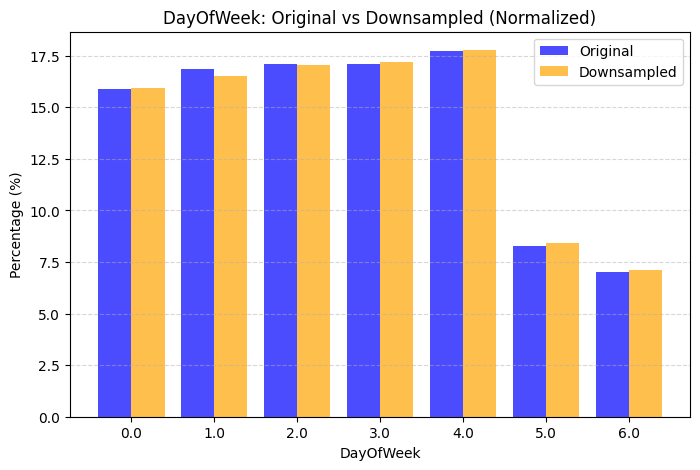

In [11]:
# Compare downsampled data with original data in terms of target variable and some features

# Features to compare
features = ['Severity', 'Hour', 'DayOfWeek']

for col in features:
    plt.figure(figsize=(8,5))
    
    if df[col].dtype in ['int64', 'float64'] and col != 'Hour':
        # Discrete numeric (Severity)
        orig_counts = df[col].value_counts(normalize=True).sort_index()
        sample_counts = df_sampled[col].value_counts(normalize=True).sort_index()
        x = np.arange(len(orig_counts))
        width = 0.4
        
        plt.bar(x - width/2, orig_counts.values*100, width=width, alpha=0.7, label='Original', color='blue')
        plt.bar(x + width/2, sample_counts.values*100, width=width, alpha=0.7, label='Downsampled', color='orange')
        plt.xticks(x, orig_counts.index)
        plt.ylabel('Percentage (%)')
    
    elif col == 'Hour':
        # Hours (0–23)
        bins = np.arange(0,25)
        # Compute histogram counts and normalize to percentage
        orig_hist, _ = np.histogram(df[col], bins=bins)
        sample_hist, _ = np.histogram(df_sampled[col], bins=bins)
        orig_hist = orig_hist / orig_hist.sum() * 100
        sample_hist = sample_hist / sample_hist.sum() * 100
        
        plt.bar(bins[:-1]-0.2, orig_hist, width=0.4, alpha=0.7, label='Original', color='blue')
        plt.bar(bins[:-1]+0.2, sample_hist, width=0.4, alpha=0.7, label='Downsampled', color='orange')
        plt.xticks(range(0,24))
        plt.ylabel('Percentage (%)')
    
    else:
        # Categorical (DayOfWeek)
        orig_counts = df[col].value_counts(normalize=True).sort_index()
        sample_counts = df_sampled[col].value_counts(normalize=True).sort_index()
        x = np.arange(len(orig_counts))
        width = 0.4
        
        plt.bar(x - width/2, orig_counts.values*100, width=width, alpha=0.7, label='Original', color='blue')
        plt.bar(x + width/2, sample_counts.values*100, width=width, alpha=0.7, label='Downsampled', color='orange')
        plt.xticks(x, orig_counts.index)
        plt.ylabel('Percentage (%)')
    
    plt.title(f'{col}: Original vs Downsampled (Normalized)')
    plt.xlabel(col)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

The bar plots above visually show that downsampled dataset has very similar distributions when comparing target variable and the features Hour and DayOfWeek.

In [12]:
# Identify categorical vs numerical columns

# Categorical / object / boolean columns
categorical_cols = df_sampled.select_dtypes(include=["object", "bool"]).columns
print("Categorical columns:", list(categorical_cols))
print("\n")

for col in categorical_cols:
    print(f"{col}: {df_sampled[col].nunique()} unique values")
print("\n")


# Numerical columns
numerical_cols = df_sampled.select_dtypes(include=["int64", "float64"]).columns
print("Numerical columns:", list(numerical_cols))
print("\n")



Categorical columns: ['ID', 'Source', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Wind_Direction', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


ID: 77284 unique values
Source: 3 unique values
Description: 72271 unique values
Street: 27382 unique values
City: 5926 unique values
County: 1243 unique values
State: 49 unique values
Zipcode: 30204 unique values
Country: 1 unique values
Timezone: 4 unique values
Airport_Code: 1552 unique values
Weather_Timestamp: 62935 unique values
Wind_Direction: 24 unique values
Weather_Condition: 74 unique values
Amenity: 2 unique values
Bump: 2 unique values
Crossing: 2 unique values
Give_Way: 2 unique values
Junction: 2 unique values
No_Exit: 2 unique valu

In [13]:
# Reassign downsampled data to df, so that later when no downsampling is applied the 
# same code below can be applied for both.

df = df_sampled

## Data Preparation

This section explains how the data is cleaned and transformed before analysis.

Tasks:
- Handling missing values
- Filtering invalid values
- Removing outliers
- Converting data types (e.g., datetime)
- Creating new variables
- Feature engineering
- Subsetting columns
- Encoding categorical variables (if used)

Examples:
- Convert Start_Time to datetime
- Create Hour or DayOfWeek
- Remove unrealistic weather values
- Filter extreme wind speeds
- Example code actions you performed.

In [14]:
# Inspect structure

df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 77284 entries, 7133276 to 6135831
Data columns (total 49 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ID                     77284 non-null  object        
 1   Source                 77284 non-null  object        
 2   Severity               77284 non-null  int64         
 3   Start_Time             69811 non-null  datetime64[ns]
 4   End_Time               69811 non-null  datetime64[ns]
 5   Start_Lat              77284 non-null  float64       
 6   Start_Lng              77284 non-null  float64       
 7   End_Lat                43315 non-null  float64       
 8   End_Lng                43315 non-null  float64       
 9   Distance(mi)           77284 non-null  float64       
 10  Description            77284 non-null  object        
 11  Street                 77157 non-null  object        
 12  City                   77281 non-null  object        
 13

End_Lat                  33969
End_Lng                  33969
Precipitation(in)        22095
Wind_Chill(F)            20015
Duration_min              7473
DayOfWeek                 7473
Start_Time                7473
End_Time                  7473
Hour                      7473
Wind_Speed(mph)           5771
Wind_Direction            1776
Visibility(mi)            1746
Humidity(%)               1715
Weather_Condition         1699
Temperature(F)            1612
Pressure(in)              1378
Weather_Timestamp         1199
Nautical_Twilight          252
Sunrise_Sunset             252
Civil_Twilight             252
Astronomical_Twilight      252
Airport_Code               224
Street                     127
Timezone                    74
Zipcode                     14
City                         3
dtype: int64


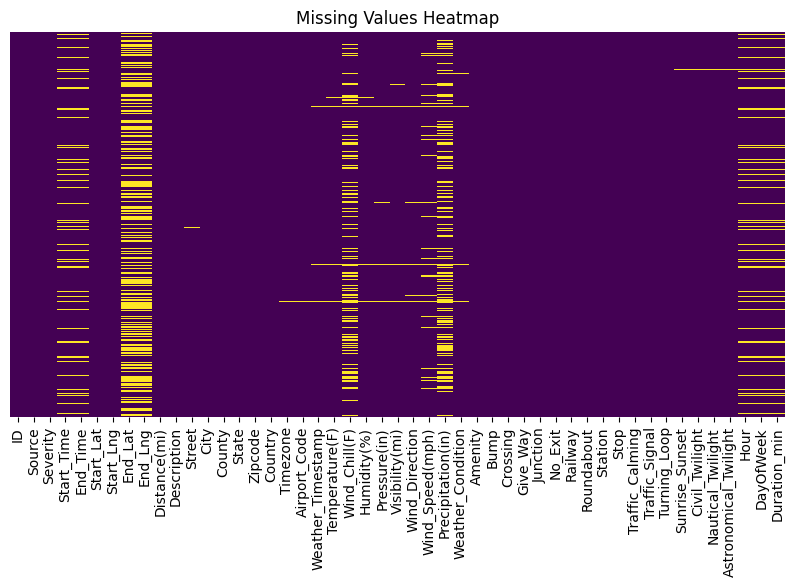

In [15]:
# Explore missing values

missing_counts = df.isnull().sum().sort_values(ascending=False)
print(missing_counts[missing_counts > 0])

# Visual check
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()


The number of missing values for each variable as shown numerically by the table above and visually by the heat map are quite large. It does not seem viable to eliminate all rows that may have missing data for all variables. Especially End_Lat and End_Lng have more than 30,000 missing values, while Precipitation(in) and Temperature(F) have missing values above 20,000. These four will be kept.

In [16]:
# Check for Null values

# Total number of rows
n_rows = len(df)

# Compute null counts and percentages
null_summary = pd.DataFrame({
    'Null_Count': df.isnull().sum(),
    'Null_Percent': df.isnull().mean() * 100
})

# Optional: sort by most missing values
null_summary = null_summary.sort_values(by='Null_Count', ascending=False)

print(null_summary)

                       Null_Count  Null_Percent
End_Lat                     33969     43.953470
End_Lng                     33969     43.953470
Precipitation(in)           22095     28.589359
Wind_Chill(F)               20015     25.897987
Duration_min                 7473      9.669531
DayOfWeek                    7473      9.669531
Start_Time                   7473      9.669531
End_Time                     7473      9.669531
Hour                         7473      9.669531
Wind_Speed(mph)              5771      7.467264
Wind_Direction               1776      2.298018
Visibility(mi)               1746      2.259200
Humidity(%)                  1715      2.219088
Weather_Condition            1699      2.198385
Temperature(F)               1612      2.085813
Pressure(in)                 1378      1.783034
Weather_Timestamp            1199      1.551421
Nautical_Twilight             252      0.326070
Sunrise_Sunset                252      0.326070
Civil_Twilight                252      0

Note that End_Lat and End_Lng have almost 44% Null values Precipitation(in) and WInd_Chill(F) have about 29% and 26% Null values. Everything above 10% is considered too much to loose.

In [17]:
# Check for NaN values

# Total number of rows
n_rows2 = len(df)

# Compute null counts and percentages
nan_summary = pd.DataFrame({
    'NaN_Count': df.isna().sum(),
    'NaN_Percent': df.isna().mean() * 100
})

# Optional: sort by most missing values
nan_summary = nan_summary.sort_values(by='NaN_Count', ascending=False)

print(nan_summary)

                       NaN_Count  NaN_Percent
End_Lat                    33969    43.953470
End_Lng                    33969    43.953470
Precipitation(in)          22095    28.589359
Wind_Chill(F)              20015    25.897987
Duration_min                7473     9.669531
DayOfWeek                   7473     9.669531
Start_Time                  7473     9.669531
End_Time                    7473     9.669531
Hour                        7473     9.669531
Wind_Speed(mph)             5771     7.467264
Wind_Direction              1776     2.298018
Visibility(mi)              1746     2.259200
Humidity(%)                 1715     2.219088
Weather_Condition           1699     2.198385
Temperature(F)              1612     2.085813
Pressure(in)                1378     1.783034
Weather_Timestamp           1199     1.551421
Nautical_Twilight            252     0.326070
Sunrise_Sunset               252     0.326070
Civil_Twilight               252     0.326070
Astronomical_Twilight        252  

In [18]:
# Handle missing values

# Drop rows with missing severity
df = df.dropna(subset=["Start_Time",
                       "End_Time",
                       "City",
                       "Zipcode",
                       "Timezone",
                       "Temperature(F)",
                       #"Wind_Chill(F)",
                       "Humidity(%)",
                       "Pressure(in)",
                       "Visibility(mi)",
                       "Wind_Direction",
                       "Wind_Speed(mph)",
                       #"Precipitation(in)",
                       "Weather_Condition",
                       
                       "Sunrise_Sunset",

                       "Hour",
                       "DayOfWeek",
                       "Duration_min"
                      ])


## Fill missing numeric values with median
#numeric_cols = ["Temperature(F)", "Wind_Speed(mph)", "Visibility(mi)"]
#df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())



End_Lat              29958
End_Lng              29958
Precipitation(in)    16784
Wind_Chill(F)        13914
Street                  86
dtype: int64


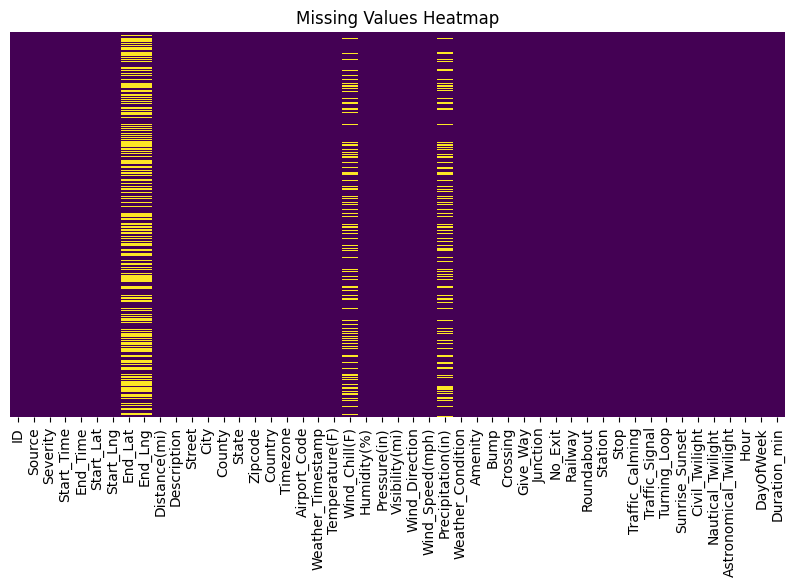

In [19]:
# Explore missing values

missing_counts = df.isnull().sum().sort_values(ascending=False)
print(missing_counts[missing_counts > 0])

# Visual check
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()


Note that NaN for columns End_Lat, End_Lng, Wind_Chill(F), and Precipitation(in) are kept because their number is too large.

array([[<Axes: title={'center': 'Temperature(F)'}>,
        <Axes: title={'center': 'Visibility(mi)'}>],
       [<Axes: title={'center': 'Wind_Chill(F)'}>,
        <Axes: title={'center': 'Precipitation(in)'}>],
       [<Axes: title={'center': 'Wind_Speed(mph)'}>,
        <Axes: title={'center': 'Distance(mi)'}>]], dtype=object)

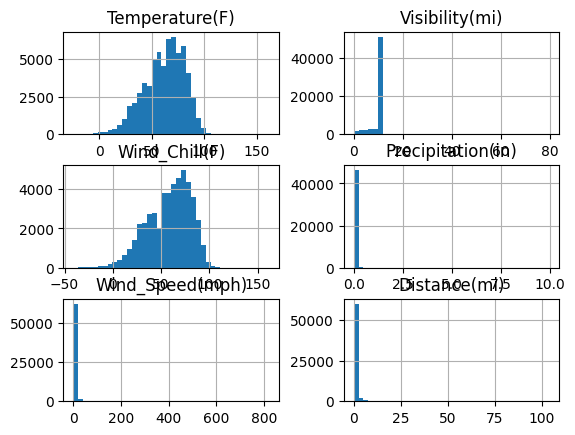

In [20]:
# Plot key weather parameters

df[["Temperature(F)", "Visibility(mi)", "Wind_Chill(F)", "Precipitation(in)", "Wind_Speed(mph)", "Distance(mi)"]].hist(bins=40)

In [21]:
# Statistics for Weather parameters

weather_cols = [
    "Temperature(F)",
    "Humidity(%)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)"
]

df[weather_cols].agg(["min", "max", "mean", "median"])

,Temperature(F),Humidity(%),Visibility(mi),Wind_Speed(mph),Precipitation(in)
min,-25.000000,2.000000,0.000000,0.000000,0.00000
max,162.000000,100.000000,80.000000,822.800000,9.99000
mean,61.724281,64.698648,9.102375,7.688238,0.00782
median,64.000000,67.000000,10.000000,7.000000,0.00000


In [22]:
# Statistics for all numeric parameters

df.select_dtypes(include="number").agg(["min", "max", "mean", "median"])

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Hour,DayOfWeek,Duration_min
min,1.000000,24.602680,-124.535726,24.681584,-124.544508,0.000000,-25.000000,-41.000000,2.000000,16.720000,0.000000,0.000000,0.00000,0.000000,0.000000,5.766667e+00
max,4.000000,48.995778,-68.226869,48.998144,-68.236807,104.302000,162.000000,162.000000,100.000000,31.120000,80.000000,822.800000,9.99000,23.000000,6.000000,1.051257e+06
mean,2.218981,36.239267,-94.554650,36.309328,-95.867865,0.525999,61.724281,57.790466,64.698648,29.527673,9.102375,7.688238,0.00782,12.364889,2.585918,4.466057e+02
median,2.000000,35.834205,-87.768690,36.279249,-88.169279,0.010000,64.000000,62.000000,67.000000,29.840000,10.000000,7.000000,0.00000,13.000000,3.000000,7.150000e+01


In [23]:
# Handle outliers

# Keep realistic weather values
df = df[(df["Temperature(F)"].between(-40, 140)) &
        (df["Wind_Speed(mph)"].between(0, 100)) &
        (df["Visibility(mi)"].between(0, 20)) &
        (df["Humidity(%)"].between(0, 100))]

array([[<Axes: title={'center': 'Temperature(F)'}>,
        <Axes: title={'center': 'Visibility(mi)'}>],
       [<Axes: title={'center': 'Wind_Chill(F)'}>,
        <Axes: title={'center': 'Precipitation(in)'}>],
       [<Axes: title={'center': 'Wind_Speed(mph)'}>,
        <Axes: title={'center': 'Distance(mi)'}>]], dtype=object)

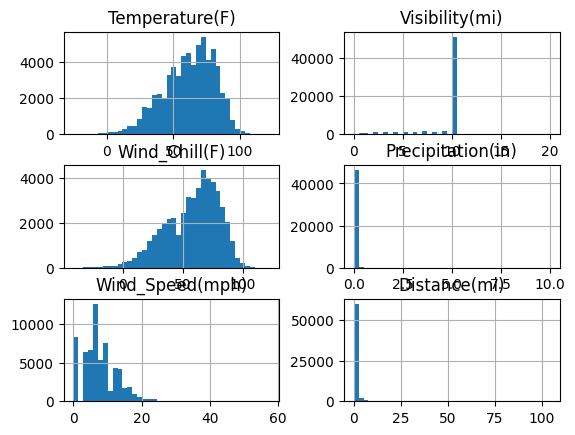

In [24]:
# Plot key weather parameters

df[["Temperature(F)", "Visibility(mi)", "Wind_Chill(F)", "Precipitation(in)", "Wind_Speed(mph)", "Distance(mi)"]].hist(bins=40)

In [25]:
# Inspect structure

df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 63358 entries, 7133276 to 6135831
Data columns (total 49 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ID                     63358 non-null  object        
 1   Source                 63358 non-null  object        
 2   Severity               63358 non-null  int64         
 3   Start_Time             63358 non-null  datetime64[ns]
 4   End_Time               63358 non-null  datetime64[ns]
 5   Start_Lat              63358 non-null  float64       
 6   Start_Lng              63358 non-null  float64       
 7   End_Lat                33450 non-null  float64       
 8   End_Lng                33450 non-null  float64       
 9   Distance(mi)           63358 non-null  float64       
 10  Description            63358 non-null  object        
 11  Street                 63272 non-null  object        
 12  City                   63358 non-null  object        
 13

In [26]:
# Engineered Features useful for Analysis

# Hour of Day
#df["Hour"] = df["Start_Time"].dt.hour
df["RushHour"] = df["Hour"].isin([7,8,9,16,17,18])

# Day of Week / Weekend
#df["DayOfWeek"] = df["Start_Time"].dt.dayofweek  # 0=Monday, 6=Sunday
df["IsWeekend"] = df["DayOfWeek"] >= 5

# Day vs. Night
df["IsNight"] = df["Sunrise_Sunset"] == "Night"

# Bad Weather Indicator
df["BadWeather"] = (
    (df["Visibility(mi)"] < 2) |
    (df["Precipitation(in)"] > 0.2) |
    (df["Weather_Condition"].str.contains("Rain|Snow|Storm|Fog", na=False))
)

# Extreme Temperatures
df["ColdTemp"] = df["Temperature(F)"] < 32
df["HotTemp"] = df["Temperature(F)"] > 90

# Visibility Risk
df["LowVisibility"] = df["Visibility(mi)"] < 3

# Wind Risk
df["HighWind"] = df["Wind_Speed(mph)"] > 30

# Combined Road Risk Score
df["RoadRiskScore"] = (df[["Traffic_Signal", "Junction", "Crossing", "Stop", "Bump", "Amenity"]].sum(axis=1))



In [27]:
# Inspect structure

df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 63358 entries, 7133276 to 6135831
Data columns (total 58 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ID                     63358 non-null  object        
 1   Source                 63358 non-null  object        
 2   Severity               63358 non-null  int64         
 3   Start_Time             63358 non-null  datetime64[ns]
 4   End_Time               63358 non-null  datetime64[ns]
 5   Start_Lat              63358 non-null  float64       
 6   Start_Lng              63358 non-null  float64       
 7   End_Lat                33450 non-null  float64       
 8   End_Lng                33450 non-null  float64       
 9   Distance(mi)           63358 non-null  float64       
 10  Description            63358 non-null  object        
 11  Street                 63272 non-null  object        
 12  City                   63358 non-null  object        
 13

## Analysis

This is where the actual findings are presented including:

- Visualizations
- Statistical summaries
- Relationships between variables
- Answers to your analytical questions

Examples:
- Accident severity vs precipitation
- Day vs night accident comparison
- Weather conditions and accident frequency
- Geographic distribution of accidents
- Correlations between variables
- Explain what the plots mean.

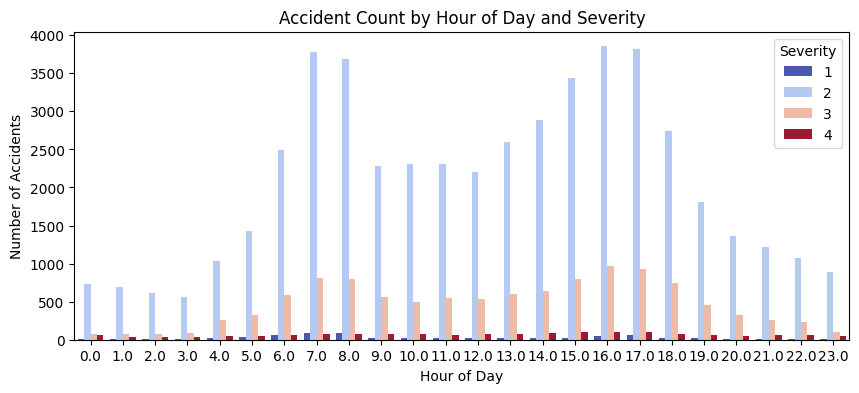

In [30]:
# Plot Accidents by Hour

plt.figure(figsize=(10,4))
sns.countplot(x="Hour", hue="Severity", data=df, palette="coolwarm")
plt.title("Accident Count by Hour of Day and Severity")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.show()

The plot above shows that most accidents occur during rush hour which manifests itself as spikes in the bar chart. 7-8 am in the morning and 4-5 pm in the afternoon have the highest number of accidents at least for severity 1 and 2. It is expected that a similar trend would show for severity 3 and 4.

So the plot proves that Hypothesis H1 for spatial and temporal patterns is correct.

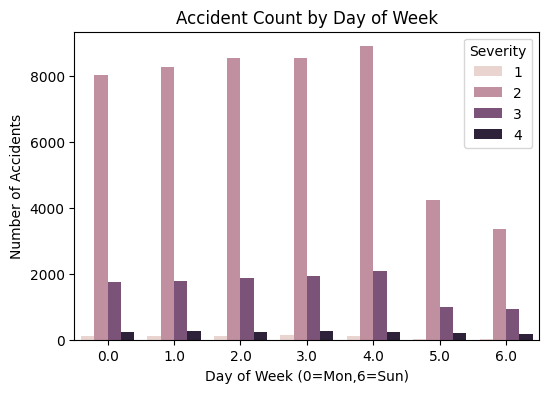

In [31]:
# Plot Accidents by Day of Week

plt.figure(figsize=(6,4))
sns.countplot(x="DayOfWeek", hue="Severity", data=df)
plt.title("Accident Count by Day of Week")
plt.xlabel("Day of Week (0=Mon,6=Sun)")
plt.ylabel("Number of Accidents")
plt.show()

The bar plot above shows clearly that weekends have lower number of accidents for all severity levels but clearly it can be seen for severity 2 and 3.

Therefore Hypothesis H2 also seems to be true.

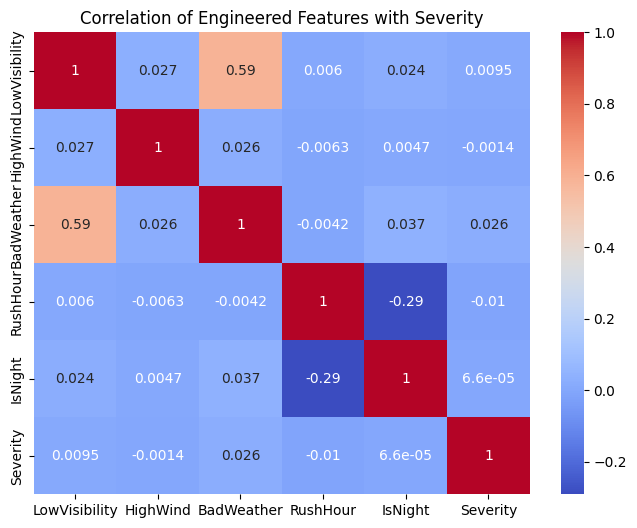

In [32]:
# Combine multiple Weather Features and Plot Correlation Matrix

features = ["LowVisibility", "HighWind", "BadWeather", "RushHour", "IsNight"]
corr = df[features + ["Severity"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation of Engineered Features with Severity")
plt.show()

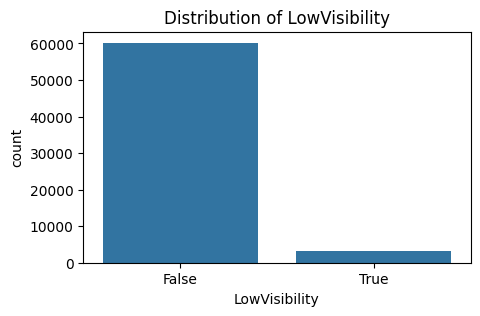

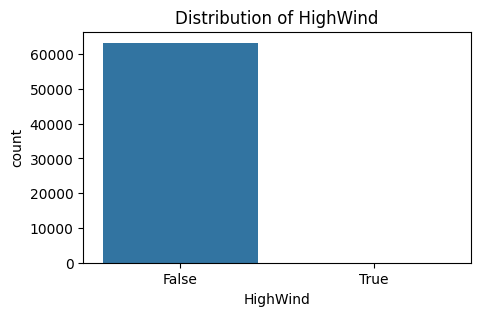

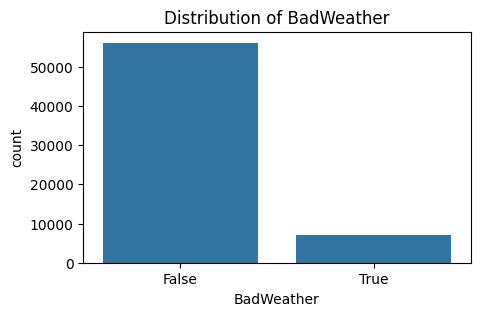

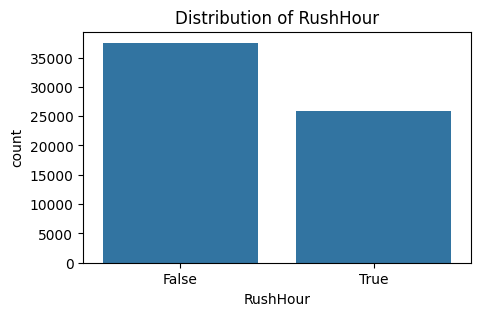

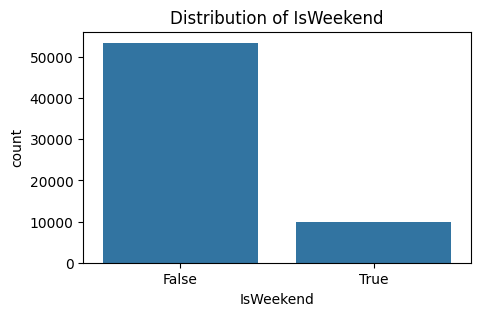

In [33]:
# PLot Distribution of Engineered Features

for col in ["LowVisibility", "HighWind", "BadWeather", "RushHour", "IsWeekend"]:
    plt.figure(figsize=(5,3))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

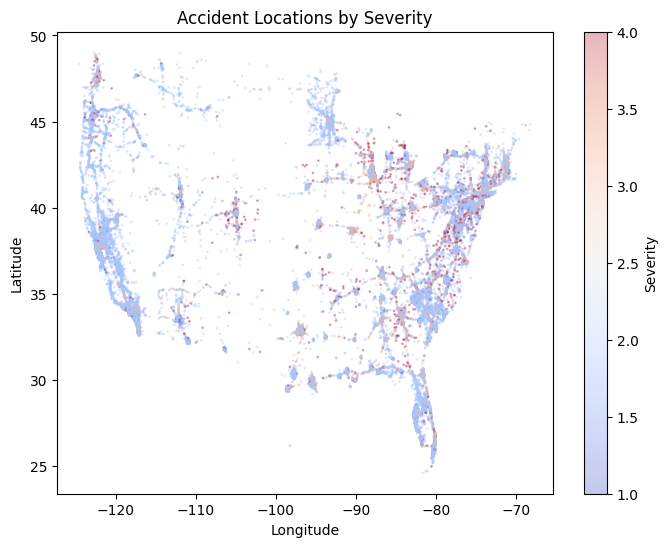

In [34]:
# Geographic Visualization

plt.figure(figsize=(8,6))
plt.scatter(df["Start_Lng"], df["Start_Lat"], s=1, c=df["Severity"], cmap="coolwarm", alpha=0.3)
plt.colorbar(label="Severity")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Accident Locations by Severity")
plt.show()

The above visualization shows that areas with larger populations tend to have higher number of accidents. The West coast and the East coast show up clearly.

In [35]:
# Import necessary Libraries

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [45]:
# Build a Random Forest Model to fit against Weather-related variables

X = df[[
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
    'Wind_Speed(mph)', 'Distance(mi)',

    'Hour', 'DayOfWeek', 'Duration_min',

    'RushHour', 'IsWeekend', 'IsNight',

    'Give_Way', 'Junction',
    'Traffic_Signal', 'Stop',

    'BadWeather', 'ColdTemp', 'HotTemp',
    'LowVisibility', 'HighWind',

    'RoadRiskScore'
]]



In [46]:

#X = df[features]
y = df["Severity"]

In [49]:
#X.head()
#y.head()

In [50]:
# Split Data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
# Run/ Fit Model

#from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbose=2   # adds progress output
)

# Fit model
rf.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.


building tree 1 of 100building tree 2 of 100

building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100


[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    0.3s


building tree 37 of 100building tree 38 of 100

building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.8s finished


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [53]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8012152777777778
              precision    recall  f1-score   support

           1       0.83      0.03      0.06       154
           2       0.82      0.96      0.88      9983
           3       0.57      0.25      0.35      2224
           4       0.50      0.01      0.02       311

    accuracy                           0.80     12672
   macro avg       0.68      0.31      0.33     12672
weighted avg       0.77      0.80      0.76     12672



[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  21 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 100 out of 100 | elapsed:    0.0s finished


The Random Forest model achieved an overall accuracy of approximately 80%, indicating good general predictive performance. However, the results reveal a strong imbalance in prediction quality across severity levels.

The model performs very well for the most common class (Severity 2), with high precision and recall, meaning it can reliably identify typical accidents. In contrast, performance for less frequent and more severe classes (Severity 3 and 4) is significantly weaker, with low recall values indicating that many of these cases are not correctly detected.

Overall, while the model is effective at predicting common accident outcomes, it struggles to identify rare but critical high-severity accidents, suggesting the need for improved handling of class imbalance in future work.

In [54]:

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

Duration_min       0.185410
Pressure(in)       0.128094
Temperature(F)     0.116004
Humidity(%)        0.111529
Distance(mi)       0.108953
Wind_Speed(mph)    0.090061
Hour               0.078597
DayOfWeek          0.054673
Visibility(mi)     0.028271
RoadRiskScore      0.020425
dtype: float64

<Axes: >

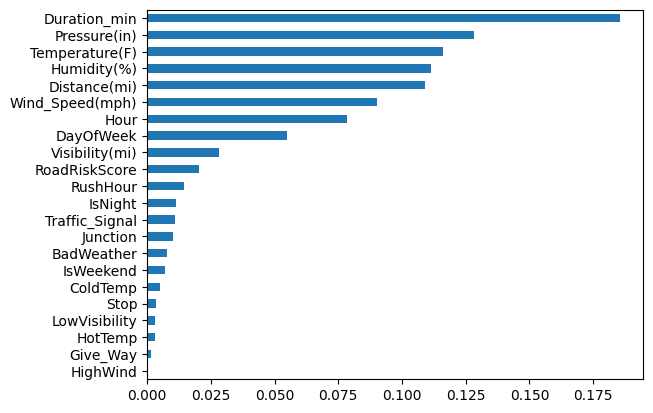

In [55]:
feature_importance.sort_values().plot(kind='barh')

The model indicates that accident duration and environmental conditions are the strongest predictors of severity, while temporal and risk-score-related features contribute less. This suggests that high-severity accidents are more influenced by the circumstances and exposure rather than just location or time alone.

In [56]:
df['Severity'].value_counts()

Severity
2    49820
3    11301
4     1600
1      637
Name: count, dtype: int64

## Evaluation

### Business Insight/Recommendation 1

Implement targeted traffic management measures during high-risk time periods (e.g., rush hours), such as adaptive traffic signal control and increased traffic monitoring to reduce congestion-related accidents.

### Business Insight/Recommendation 2

Enhance driver awareness and safety during adverse weather conditions by deploying real-time warning systems and dynamic road signage that adjust to visibility, precipitation, and temperature changes.

### Business Insight/Recommendation 3

Improve road safety by optimizing high-risk locations (e.g., intersections and junctions) through better lighting, clearer signage, and the installation of traffic control devices such as signals or roundabouts.

### Tableau Dashboard link

## Conclusion and Next Steps

The analysis highlights that traffic accidents are influenced by a combination of temporal, environmental, and infrastructure-related factors. Patterns across time, weather conditions, and road features suggest that accident occurrence and severity are not random but driven by identifiable risk factors. These insights can support more targeted and data-driven approaches to improving road safety.

For future work, the analysis could be extended by incorporating additional data sources such as traffic volume or demographic information. More advanced modeling techniques and deeper geographic analysis (e.g., hotspot detection) could further improve predictive accuracy and provide more detailed insights for decision-makers.